# **5.2 합성곱 신경망 맛보기**

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

In [2]:
#CPU, GPU 장치 확인
device =torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

**GPU 사용**

* GPU 사용할 때는 다음과 같은 코드 이용


```
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = Net()
model.to(device)
```
* 다수의 GPU를 사용하면 nn.DataParallel 이용


```
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Net()
if torch.cuda.device_count() > 1:
  model = nn.DataParallel(net)
model.to(device)
```
* 배치 크기가 알아서 각 GPU로 분배됨->GPU 수 만큼 배치 크기 늘려주어야함




In [3]:
#fashion_mnist 데이터셋 내려받기
train_dataset = torchvision.datasets.FashionMNIST("../chap05/data", download=True, transform=transforms.Compose([transforms.ToTensor()]))
test_dataset = torchvision.datasets.FashionMNIST("../chap05/data", download=True, train=False, transform=transforms.Compose([transforms.ToTensor()]))

100%|██████████| 26.4M/26.4M [00:00<00:00, 113MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.76MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 62.4MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 15.4MB/s]


* torchvision.datasets는 torch.utils.data.Dataset의 하위클래스로 다양한 데이터셋(CIFAR, COCO, MNIST, ImageNet 등)을 포함


```
torchvision.datasets.FashionMNIST("../chap05/data", download=True, tranform=transforms.Compose([transforms.ToTensor()]))
```
1. 첫번째 파라미터: FashionMNIST를 내려받을 위치를 지정
2. download:download를 True로 변경해주면 첫번째 파라미터의 위치에 해당 데이터셋이 있는지 확인한 후 내려받음
3. transform: 이미지를 텐서(0~1)로 변경



In [4]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=100)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=100)

* torch.utils.data.DataLoader()를 사용해 원하는 크기의 배치 단위로 데이터를 불러오거나, 순서가 무작위로 섞이도록 할 수 있음


```
torch.utils.data.DataLoader(train_dataset, batch_size=100)
```
1. 첫번째 파라미터: 데이터를 불러올 데이터셋 지정
2. batch_size: 데이터를 배치로 묶어줌. 여기에서는 batch_size=100으로 지정했기 때문에 100개 단위로 데이터를 묶어서 불러옴


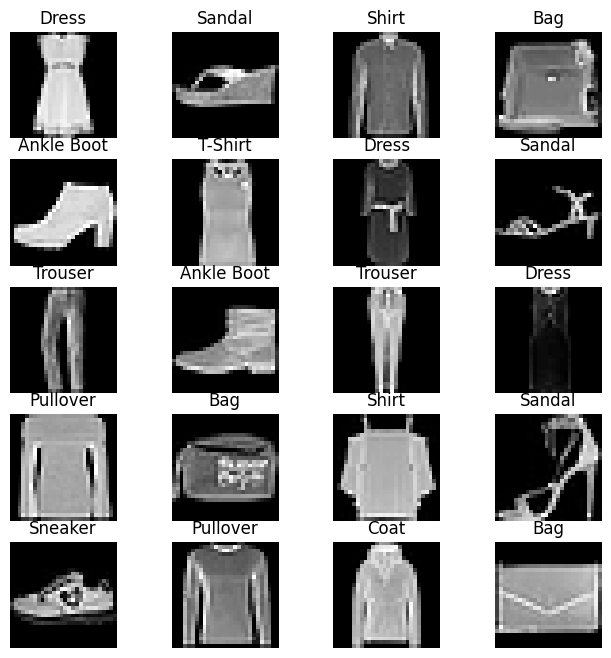

In [5]:
labels_map = {0: 'T-Shirt', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat', 5:'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle Boot'}

fig = plt.figure(figsize=(8,8));
columns = 4;
rows = 5;
for i in range(1,columns*rows +1):
  img_xy = np.random.randint(len(train_dataset));
  img = train_dataset[img_xy][0][0,:,:]
  fig.add_subplot(rows, columns, i)
  plt.title(labels_map[train_dataset[img_xy][1]])
  plt.axis('off')
  plt.imshow(img, cmap='gray')
plt.show()

1. np.random은 무작위로 데이터를 생성할 때 사용. 또한 np.random.randint()는 이산형 분포를 갖는 데이터에서 무작위 표본을 추출할 때 사용. random.randint(len(train_dataset)) 의미는 0~(train_dataset)) 값을 갖는 분포에서 랜덤한 숫자 한개를 생성하라는 의미

* random.randint와 유사하게 사용되는 random.rand와 random.randn을 예시로





In [6]:
import numpy as np
np.random.randint(10) #0~10의 임의의 숫자를 출력

7

In [7]:
np.random.randint(1,10)

6

In [8]:
np.random.rand(8) #0~1사이의 정규표준분포 난수를 행렬로 1*8로 출력

array([0.90374632, 0.42386859, 0.43409735, 0.38494128, 0.32287127,
       0.00113651, 0.08293545, 0.95465027])

In [9]:
np.random.rand(4,2)

array([[0.01723567, 0.29924071],
       [0.65882116, 0.06779755],
       [0.72506598, 0.33168926],
       [0.20845357, 0.06626534]])

In [10]:
np.random.randn(8) #평균이 0이고, 표준편차가 1인 가우시안 정규분포 난수를 행렬로 1*8 출력

array([-2.61094164, -1.21098023,  1.01469863,  0.75179861,  1.50012312,
        0.4296452 , -0.14411403,  1.32524218])

In [11]:
np.random.randn(4,2)

array([[-0.39039462,  0.71360462],
       [ 0.42715345,  0.14093398],
       [-0.46470079,  0.36522102],
       [ 0.23770068, -1.25155615]])

2. train_dataset을 이용한 3차원 배열을 생성

In [12]:
import numpy as np
examp = np.arange(0,100,3)
examp.resize(6,4)
examp

array([[ 0,  3,  6,  9],
       [12, 15, 18, 21],
       [24, 27, 30, 33],
       [36, 39, 42, 45],
       [48, 51, 54, 57],
       [60, 63, 66, 69]])

In [13]:
examp[3] #3행에 해당하는 모든 요소값들을 출력

array([36, 39, 42, 45])

In [14]:
examp[3,3] #3행의 3번째 열에 대한 값을 출력

np.int64(45)

In [15]:
examp[3][3] #3행의 3번째 열에 대한 값을 출력하기 때문에 바로 앞의 결과와 동일

np.int64(45)

In [16]:
examp = np.arange(0,500,3)
examp.resize(3,5,5)
examp

array([[[  0,   3,   6,   9,  12],
        [ 15,  18,  21,  24,  27],
        [ 30,  33,  36,  39,  42],
        [ 45,  48,  51,  54,  57],
        [ 60,  63,  66,  69,  72]],

       [[ 75,  78,  81,  84,  87],
        [ 90,  93,  96,  99, 102],
        [105, 108, 111, 114, 117],
        [120, 123, 126, 129, 132],
        [135, 138, 141, 144, 147]],

       [[150, 153, 156, 159, 162],
        [165, 168, 171, 174, 177],
        [180, 183, 186, 189, 192],
        [195, 198, 201, 204, 207],
        [210, 213, 216, 219, 222]]])

In [17]:
examp[2][0][3]

np.int64(159)

In [18]:
#심층 신경망 모델 생성
class FashionDNN(nn.Module):
  def __init__(self):
    super(FashionDNN, self).__init__()
    self.fc1 = nn.Linear(in_features=784, out_features=256)
    self.drop = nn.Dropout(0.25)
    self.fc2 = nn.Linear(in_features = 256, out_features = 128)
    self.fc3 = nn.Linear(in_features=128, out_features=10)

  def forward(self, input_data):
    out = input_data.view(-1,784)
    out = F.relu(self.fc1(out))
    out = self.drop(out)
    out = F.relu(self.fc2(out))
    out = self.fc3(out)
    return out

1. class 형태의 모델은 항상 torch.nn.Module을 상속받음.__init__()은 객체가 갖는 속성 값을 초기화. super(FashionDNN, self).__init__()은 FashionDNN이라는 부모 클래스를 상속

**객체**
* 객체 지향 프로그램은 프로그래밍에서 필요한 데이터를 추상화해 속성이나 행동, 동작, 특징 등을 객체로 만들고, 그 객체들이 서로 유기적으로 동작하도록함
* 객체란 메모리를 할당받아 프로그램에서 사용되는 모든 데이터를 의미
* 객체명 = 클래스명()


**클래스와 함수**
* 함수: 하나의 특정 작업을 수행하기 위해 독립적으로 설계된 프로그램 코드
* 함수의 호출을 특정 작업만 수행할 뿐, 그 결괏값을 계속 사용하기 위해서는 반드리 어딘가에 따로 그 값을 저장해야함.
* 클래스: 함수뿐만 아니라 관련된 변수까지도 한꺼번에 묶어서 관리하고 재사용할 수 있게 해줌


In [19]:
def add(num1, num2):
  result = num1+num2
  return result

print(add(1,2))
print(add(2,3))

3
5


In [20]:
#class에 대한 코드
class Calc:
  def __init__(self):
    self.result = 0

  def add(self, num1, num2):
    self.result = num1 + num2
    return self.result

obj1 = Calc()
obj2 = Calc()

print(obj1.add(1,2))
print(obj1.add(2,3))
print('---------------')
print(obj2.add(2,2))
print(obj2.add(2,3))

3
5
---------------
4
5


2. nn은 딥러닝 모델 구성에 필요한 모듈이 모여 있는 패키지.
Linear는 단순 선형 회귀 모델을 만들 때 사용.
* in_features: 입력의 크기
* out_features: 출력의 크기

실제로 데이터 연산이 진행되는 forward() 부분에는 첫번째 파라미터 값만 넘겨주게 되며, 두번 째 파라미터에서 정의된 크기가 forward() 연산의 결과가 됨.

3. torch.nn.Dropout(p)는 p만큼의 비율로 텐서의 값이 0이 되고, 0이 되지 않는 값들은 기존 값에 (1/(1-p))만큼 곱해져 커짐.
* p=0.3이라는 의미 : 전체 값 중 0.3의 확률로 0이 된다는 것. 0이 되지 않는 0.7에 해당하는 값은 (1/(1-0.7))만큼 커짐

4. forward() 함수는 모델이 학습 데이터를 입력받아서 순전파 학습을 진행시킴, 반드시 forward 라는 이름의 함수. 객체를 데이터와 함께 호출하면 자동 실행. 이때, 순전파 연산이란 H(x)^2 식에 입력 x로부터 예측된 y를 얻는 것

5. view: 넘파이의 reshape과 비슷. 텐서 크기를 변경해주는 역할. 첫번째 차원이 -1 값이면 파이토치에게 맡겨 차원 설정.

6. 활성화 함수 지정 시
* F.relu(): forward() 함수에서 정의


```
import torch.nn.functinal as F
inputs = torch.randn(64,3,244,244)
weight = torch.randn(64,3,3,3)
bias = torch.randn(64)
outputs = F.conv2d(inputs, weight, bias, padding=1)
```


* nn.ReLU(): __init__() 함수에서 정의


```
import torch
import torch.nn as nn

inputs = torch.randn(64,3,244,244)
conv = nn.Conv2d(in_channels =3, out_channels = 64, kernel_size = 3, padding=1)
outputs = conv(inputs)
layer = nn.Conv2d(1,1,3)
```



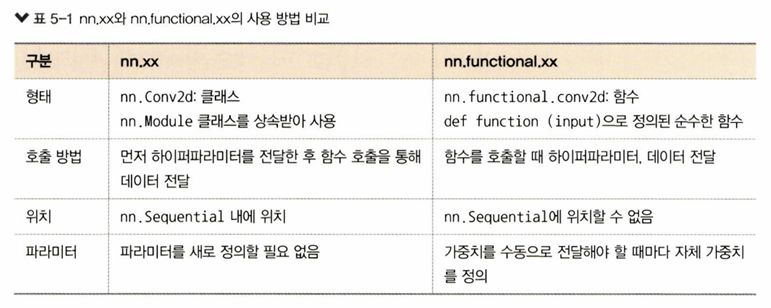

In [21]:
#파라미터 정의
learning_rate= 0.001;
model =FashionDNN();
model.to(device)

criterion=nn.CrossEntropyLoss();
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate); #Adam 사용
print(model)

FashionDNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


In [25]:
#모델 학습
num_epochs = 5
count = 0
loss_list = []
iteration_list = []
accuracy_list = []

predictions_list=[]
labels_list = []

for epoch in range(num_epochs):
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    train = Variable(images.view(100, 1, 28, 28))
    labels = Variable(labels)

    outputs = model(train)
    loss = criterion(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    count += 1

    if not (count% 50):
      total = 0
      correct = 0
      for images, labels in test_loader:
        images, labels  = images.to(device), labels.to(device)
        labels_list.append(labels)
        test = Variable(images.view(100,1,28,28))
        outputs = model(test)
        predictions = torch.max(outputs,1)[1].to(device)
        predictions_list.append(predictions)
        correct += (predictions == labels).sum()
        total += len(labels)

      accuracy = correct *100/total
      loss_list.append(loss.data)
      iteration_list.append(count)
      accuracy_list.append(accuracy)

    if not (count % 500):
      print("Iteration: {}, Loss:{}, Accuracy:{}%".format(count, loss.data, accuracy))

Iteration: 500, Loss:0.5774596333503723, Accuracy:84.0%
Iteration: 1000, Loss:0.442839652299881, Accuracy:84.48999786376953%
Iteration: 1500, Loss:0.3175017535686493, Accuracy:84.5199966430664%
Iteration: 2000, Loss:0.42518627643585205, Accuracy:85.1500015258789%
Iteration: 2500, Loss:0.293560653924942, Accuracy:85.51000213623047%
Iteration: 3000, Loss:0.2866552770137787, Accuracy:86.44000244140625%


1. 리스트를 만들어 빈 배열 행령 생성
2. for 구문 이용해 레코드 가져옴
3. 모델이 데이터를 처리하기 위해 모델과 데이터가 동일한 장치에 있도록함
4. Autograd: 자동 미분 수행 파이토치 패키지. tape를 사용해 자동 미분 저장. 역전파에서 저장된 값들 꺼내서 사용
5. 분류 문제에 대한 정확도는


```
classification accuracy = correct predictions /total predictions
```
* 여기에 100을 곱해 백분율로 표현


* 오분류율 또는 오류율 표현

```
error rate = (1-(correct predictions /total predictions))*100
```

**분류 문제에서 클래스가 3개 이상일때 주의사항**
* 정확도 값이 모든 클래스가 동등하게 고려된 것인지, 특정 클래스의 분류가 높았던 것인지 알 수 없음
* 정확도가 90% 이상이라고 할때, 100개의 데이터 중 90개가 하나의 클래스에 속할 경우 90% 정확도는 높다고 할 수 X. 데이터 특성에 따라 정활동 관측해야함


In [31]:
from torch.nn.modules.batchnorm import BatchNorm2d
#합성곱 네트워크 생성
class FashionCNN(nn.Module):
  def __init__(self):
    super(FashionCNN, self).__init__()
    self.layer1 = nn.Sequential(
        nn.Conv2d(in_channels = 1, out_channels=32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.layer2 = nn.Sequential(
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.fc1 = nn.Linear(in_features=64*6*6, out_features = 600)
    self.drop = nn.Dropout2d(0.25)
    self.fc2 = nn.Linear(in_features=600, out_features = 120)
    self.fc3 = nn.Linear(in_features=120, out_features=10)
  def forward(self,x):
    out = self.layer1(x)
    out = self.layer2(out)
    out = out.view(out.size(0), -1)
    out = self.fc1(out)
    out = self.drop(out)
    out = self.fc2(out)
    out = self.fc3(out)
    return out

1. nn.Sequential을 사용하면 __init()에서 사용할 네트워크 모델들을 정의 + forward() 함수에서 구현될 순전파를 계층 형태로 좀 더 가독성이 뛰어난 코드로 작성 가능. nn.Sequential은 계층을 차례로 쌓을 수 있도록 Wx+b와 같은 수식과 활성화 함수를 연결.
2. 합성곱층: 합성곱 연산을 통해서 이미지의 특징 추출
* 커널이라는 n*m 크기의 행렬이 높이*너비 크기의 이미지를 처음부터 끝까지 훑으면서 각 원소 값끼리 곱한 후 모두 더한 값을 출력


```
nn.Conv2d(in_channels = 1, out_channels=32, kernel_size =3, padding=1)
```
* 채널 == 깊이
* in_channels: 입력 채널의 수
* out_channels: 출력 채널의 수
* kernel_size: 커널 크기를 의미(== 필터). 이미지 특징을 찾아내기 위한 공용 파라미터이며, CNN에서 학습 대상은 필터 파라미터가 됨. > 입력 데이터를 스트라이드 간격으로 순회하면서 합성곱 계산
* padding: 패딩의 크기

3. BatchNorm2d: 학습 과정에서 각 배치 단위별로 데이터가 다양한 분포를 가지더라도 평균과 분산을 이용해 정규화하는 것을 의미

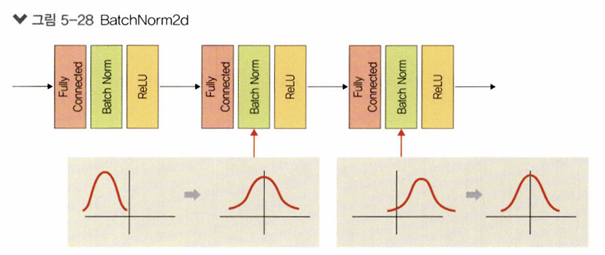

4. MaxPool2d: 이미지 크기를 축소시키는 용도
* 풀링 계층: 합성곱층의 출력 데이터를 입력으로 받아서 출력 데이터의 크기를 줄이거나 특정 데이터를 강조하는 용도로 사용됨.


```
nn.MaxPool2d(kernel_size=2, strid = 2)
```
* kernel_size = m*n 행렬로 구성된 가중치
* stride - 입력 데이터에 커널을 적용할 때 이동할 간격 의미

5. Conv2d에서 사용하는 하이퍼파라미터 값들에 따라 출력 크기가 달라짐


```
nn.Linear(in_features = 64*6*6, out_features = 600)
```





**Conv2d 계층에서 출력 크기 구하는 공식**
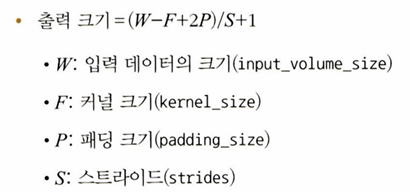

**MaxPool2d 계층에서의 출력 크기 구하는 공식**
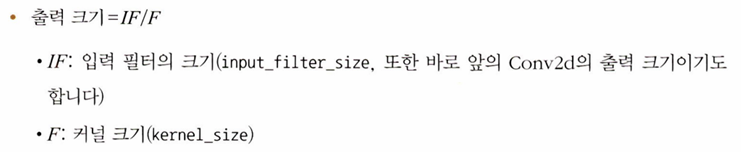

6. 합성곱층->완전연결층으로 변경시 데이터 형태를 1차원으로 변경
* out.size(0)은 결국 100을 의미

In [32]:
learning_rate = 0.001;
model = FashionCNN();
model.to(device)

criterion = nn.CrossEntropyLoss();
optimizer = torch.optim.Adam(model.parameters(), lr= learning_rate)
print(model)

FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=600, bias=True)
  (drop): Dropout2d(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
)


In [33]:
num_epochs = 5
count =0
loss_list =[]
iteration_list = []
accuracy_list = []

predictions_list = []
labels_list = []

for epoch in range(num_epochs):
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)
    train=Variable(images.view(100,1,28,28))
    labels = Variable(labels)

    outputs = model(train)
    loss = criterion(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    count += 1

    if not (count % 50):
      total = 0
      correct = 0
      for images, labels in test_loader:
        images, labesl = images.to(device), labels.to(device)
        labels_list.append(labels)
        test = Variable(images.view(100,1,28,28))
        outputs = model(test)
        predictions = torch.max(outputs, 1)[1].to(device)
        predictions_list.append(predictions)
        correct += (predictions == labels).sum()
        total += len(labels)

      accuracy = correct *100/total
      loss_list.append(loss.data)
      iteration_list.append(count)
      accuracy_list.append(accuracy)
    if not (count % 500):
      print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  return F.dropout2d(input, self.p, self.training, self.inplace)


Iteration: 500, Loss: 0.4530601501464844, Accuracy: 87.19999694824219%
Iteration: 1000, Loss: 0.3570161461830139, Accuracy: 87.18000030517578%
Iteration: 1500, Loss: 0.37600651383399963, Accuracy: 88.16999816894531%
Iteration: 2000, Loss: 0.23967356979846954, Accuracy: 89.31999969482422%
Iteration: 2500, Loss: 0.12332892417907715, Accuracy: 89.55000305175781%
Iteration: 3000, Loss: 0.19243937730789185, Accuracy: 90.18000030517578%
